In [11]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Load Dataset
PATH = r'D:\Project code\financial-crime-ai\data\creditcard.csv'
data = pd.read_csv(PATH)

print(data.shape)
data.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Anomaly detection works without labels
X = data.drop("Class", axis=1)

In [4]:
# Train Isolation Forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42
)

model.fit(X)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.002
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [ ]:
# Predict Anomaly Scores
scores = model.decision_function(X)

predictions = model.predict(X)

In [6]:
# 1  => normal
# -1 => anomaly
data["anomaly"] = predictions


In [7]:
# Compare With Real Fraud
pd.crosstab(data["anomaly"], data["Class"])

Class,0,1
anomaly,,
-1,430,140
1,283885,352


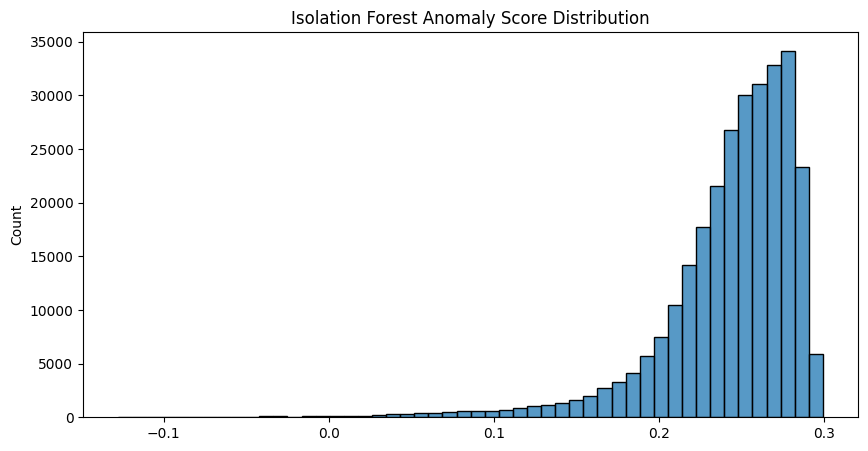

In [8]:
# Visualize Anomaly Score
plt.figure(figsize=(10,5))

sns.histplot(scores, bins=50)

plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

In [9]:
# Top Suspicious Transactions
data["anomaly_score"] = scores

data.sort_values("anomaly_score").head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,anomaly,anomaly_score
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.16,0,-1,-0.127479
173353,121450.0,-28.262775,-26.551515,-15.930586,6.945207,-19.203497,13.461737,23.718783,-9.419314,5.264773,...,-22.459170,1.771003,-3.684737,-0.106886,4.071877,-2.383081,4861.64,0,-1,-0.125948
173054,121340.0,-22.132223,-19.815536,-11.183644,4.829787,-13.128465,10.689779,18.257057,-8.685409,5.250410,...,-18.416215,1.376122,-2.965101,0.149369,4.077221,-1.975801,4543.64,0,-1,-0.114192
176335,122723.0,-35.274010,-34.889342,-15.070015,9.211564,-6.226835,3.828063,10.778805,-6.462003,6.588395,...,-26.429741,1.765486,-4.564506,-0.594620,1.110848,-0.714247,1676.60,0,-1,-0.113228
206255,136137.0,-40.042537,-38.430842,-21.277176,10.527243,-16.296090,8.799515,19.553200,-6.221785,6.121324,...,-20.034848,1.575385,-4.196468,-0.851794,0.375152,-1.178134,1676.60,0,-1,-0.111564
206228,136124.0,-37.054295,-35.699829,-19.880878,9.552849,-16.701866,9.741883,21.014587,-6.414390,5.751017,...,-14.414207,1.223594,-3.129609,-0.689271,0.289897,-1.181892,1676.60,0,-1,-0.110872
231454,146772.0,-35.905105,-31.041362,-19.472908,9.216960,-18.863553,10.713326,16.687265,-9.609234,3.296559,...,-19.331255,0.987774,-2.180899,-0.172480,6.228140,-2.830091,3552.96,0,-1,-0.109154
220090,142019.0,-37.558067,-29.335992,-24.962322,8.413616,-35.182120,21.550496,36.877368,-8.915982,5.046566,...,-7.800902,1.272716,1.965365,0.767817,3.248189,13.013546,5964.95,0,-1,-0.109109
58465,48401.0,-36.802320,-63.344698,-20.645794,16.715537,-20.672064,7.694002,24.956587,-4.730111,-2.687312,...,-17.173665,1.180700,-7.025783,-2.534330,-3.602479,3.450224,19656.53,0,-1,-0.106756
74699,55709.0,-16.950064,-16.417395,-12.523381,6.555638,-27.752964,18.072031,28.504065,-10.152220,2.124673,...,-10.855949,1.550407,-0.502172,0.821714,12.152401,-4.009839,8790.26,0,-1,-0.102156


In [12]:
# Save Anomaly Detection Model
joblib.dump(model, "../models/anomaly_detection_model.pkl")

['../models/anomaly_detection_model.pkl']

### Key Insights

The anomaly detection model flagged 140 fraudulent transactions as anomalous,
representing approximately 28% of all fraud cases.

While the model does not detect all fraudulent transactions,
it successfully identifies behavioral anomalies that differ from typical transaction patterns.

This demonstrates the importance of combining supervised fraud detection
with unsupervised anomaly detection in financial crime monitoring systems.


| System            | Fraud Detected               |
| ----------------- | ---------------------------- |
| Supervised Model  | Detects known fraud patterns |
| Anomaly Detection | Detects unusual behavior     |

Together they create a strong detection system.